# 10.1.2 微分噪声与积分抗饱和

## 学习目标与先修知识

实现离散PID与条件积分，比较噪声和执行限幅。

先修：10.1.1误差、积分与实际执行输入（input）；第5.2章测量噪声（measurement noise）。

## 具体问题

控制器看到的是带噪读数。加入“预测误差变化”的微分项后，响应可能更快，也可能让执行器对测量噪声不停抖动。积分在饱和时还可能持续积累。

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

对固定的误差序列[2,2,−1,0]，直接重放请求、限幅和积分状态（state），留意解除饱和的时刻。

In [2]:
errors=[2.,2.,-1.,0.];print("第一步候选积分、请求：",2.,1.*2+.5*2)

第一步候选积分、请求： 2.0 3.0


## 模型假设

离散PID使用 $e_n=r-y_n$、步长h>0、后向差分 $D_n=(e_n-e_{n-1})/h$；初始I=0、先前误差0。执行上限对称，条件积分规则与10.1.1相同。测量噪声只加到读数，动力学扰动另行表示。微分项不做滤波，便于明确看到噪声风险。

## 数学解释与推导

候选积分 $\tilde I_{n+1}=I_n+he_n$，候选输入
$$\tilde u_n=k_pe_n+k_i\tilde I_{n+1}+k_d\frac{e_n-e_{n-1}}h.$$
若裁剪后 $\tilde u_n$ 与误差同向且已超限，则令 $I_{n+1}=I_n$、重新计算请求；否则接受候选积分。最终实际输入再次裁剪。微分项要求 $[k_d]=1$（本例输入为U/T，差分为U/T）。

测量噪声在相邻时刻从+δ变成−δ时，即使真实误差不变，差分噪声可达到 $2\delta/h$。减小h而不改变噪声幅度会放大这一项。因此PID增益（gain）和滤波设计必须结合测量、执行限幅和采样（sampling）设置。本节对误差作差分；设定值突然改变而测量暂时不变时，也会出现很大的微分冲击（derivative kick）。对测量量作微分可避开设定值阶跃带来的冲击，滤波则用于减轻高频放大；下面仍按给定的误差差分计算。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def pid_trace(errors, dt, kp, ki, kd, limit):
    integral, previous = 0.0, 0.0
    rows = []
    for error in errors:
        trial = integral + error * dt
        derivative = (error - previous) / dt
        requested = kp * error + ki * trial + kd * derivative
        actual = max(-limit, min(limit, requested))
        if actual != requested and error * requested > 0:
            trial = integral
            requested = kp * error + ki * trial + kd * derivative
            actual = max(-limit, min(limit, requested))
        rows.append([requested, actual, trial])
        integral, previous = trial, error
    return rows

## 对照实验

先重放有限历史，再对同一真实误差叠加交替测量噪声，比较不同微分增益下的请求波动；另一图显示条件积分如何阻止饱和方向的累积。

误差序列下 [请求,实际,积分]： [[2.0, 2.0, 0.0], [2.0, 2.0, 0.0], [-1.5, -1.5, -1.0], [-0.5, -0.5, -1.0]]


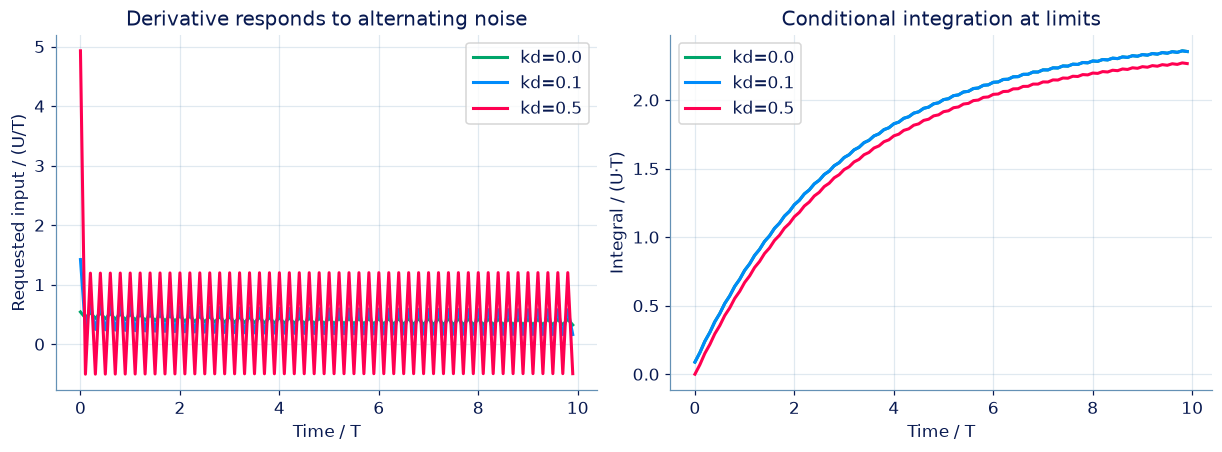

In [4]:
rows=pid_trace([2.,2.,-1.,0.],1.,1.,.5,0.,2.)
print('误差序列下 [请求,实际,积分]：',rows)
time=np.arange(100)*.1;true_error=.8*np.exp(-time/3)
noise=.08*(-1.)**np.arange(100);measured=true_error+noise
fig,axes=plt.subplots(1,2,figsize=(11,4))
for kd,color in [(0.,GREEN),(.1,BLUE),(.5,PINK)]:
    arr=np.array(pid_trace(measured.tolist(),.1,.6,.15,kd,2.))
    axes[0].plot(time,arr[:,0],label=f'kd={kd}',color=color)
    axes[1].plot(time,arr[:,2],label=f'kd={kd}',color=color)
axes[0].set(xlabel='Time / T',ylabel='Requested input / (U/T)',title='Derivative responds to alternating noise');axes[0].legend()
axes[1].set(xlabel='Time / T',ylabel='Integral / (U·T)',title='Conditional integration at limits');axes[1].legend();plt.show()

## 结果解释

本例未对微分项滤波，因此大kd把交替噪声直接放大。右图的积分不总是严格上升，因为达到执行上限且误差仍推动同向限幅时会冻结；误差换向时又可能恢复更新。这里展示的是规则行为，不用一次轨迹（trajectory）断言最佳参数（parameter）。

### 独立核对

用两种步长对同一±0.08 U噪声跳变手算差分幅度，再核对代码在无误差和空序列的边界。

In [5]:
assert np.isclose((.08-(-.08))/.1,10*((.08-(-.08))/1.))
assert pid_trace([],1.,1.,1.,1.,2.)==[]
assert pid_trace([0.],1.,1.,1.,1.,2.)==[[0.,0.,0.]]
assert rows[0]==[2.,2.,0.]
print('噪声/步长比例、初态和空历史边界通过。')

噪声/步长比例、初态和空历史边界通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：重放误差历史中的 PID

按给定误差时间序列（time series）从积分0和前一误差0开始，逐步使用后向差分 D=(e_t−e_{t−1})/dt 与 10.1.1 的条件积分。每步返回请求、真实输入（input）和积分；序列无须由本函数生成。

**函数与代码模板**

```python
def solve(
    errors: list[float],
    dt: float,
    kp: float,
    ki: float,
    kd: float,
    limit: float,
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `errors` | `list[float]` | 按时间顺序给定的误差。 | U |
| `dt` | `float` | 固定步长。 | T |
| `kp` | `float` | 比例增益（gain）。 | 1/T |
| `ki` | `float` | 积分增益。 | 1/T² |
| `kd` | `float` | 微分增益。 | 1 |
| `limit` | `float` | 执行上限。 | U/T |

**返回值**

直接返回 rows（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rows` | `list[list[float]]` | 每步 [请求输入,真实输入,更新后积分]。 | 混合，依列说明 |

**计算规则**

初始 I=0,e_previous=0。试算 I+e·dt 和 kp·e+ki·I+kd·(e−e_previous)/dt；限幅后按 e·request>0 的条件冻结积分并重算该步；随后更新 previous。

**约束与边界**

- 输入均为有限数；只需实现题定模型（model），不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| errors | 按时间顺序给定的误差。 | [2.0, 2.0, -1.0, 0.0] | U |
| dt | 固定步长。 | 1 | T |
| kp | 比例增益（gain）。 | 1 | 1/T |
| ki | 积分增益。 | 0.5 | 1/T² |
| kd | 微分增益。 | 0 | 1 |
| limit | 执行上限。 | 2 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
errors = [2.0, 2.0, -1.0, 0.0]
dt = 1.0
kp = 1.0
ki = 0.5
kd = 0.0
limit = 2.0

result = solve(errors, dt, kp, ki, kd, limit)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rows | 每步 [请求输入,真实输入,更新后积分]。 | [[2.0, 2.0, 0.0], [2.0, 2.0, 0.0], [-1.5, -1.5, -1.0], [-0.5, -0.5, -1.0]] | 混合，依列说明 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[2.0, 2.0, 0.0],
                   [2.0, 2.0, 0.0],
                   [-1.5, -1.5, -1.0],
                   [-0.5, -0.5, -1.0]]
```

**样例解释**

第一步候选输入3超过上限，积分冻结；第二步仍保持。误差转负后应重新检查方向与释放。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：重放误差历史中的 PID](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/practice/?question=p10-pid-history)

### 第 2 题 · 单项选择题：为何微分会放大高频噪声

同样的真实误差保持不变，两次测量噪声（measurement noise）交替为+0.1 U与−0.1 U，dt 从1 T缩到0.1 T。D=(e_t−e_previous)/dt 的噪声幅度怎样变化？

- **A.** 约放大10倍。
- **B.** 约缩小10倍。
- **C.** 完全不变，因为真实误差不变。
- **D.** 只要增加kd便能消除测量噪声。

[作答：为何微分会放大高频噪声](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/practice/?question=p10-derivative-noise)

### 第 3 题 · 单项选择题：何时冻结积分

正向上限为2 U/T，当前请求超过上限。下列哪种误差方向按本节条件积分规则要求冻结积分？

- **A.** e>0，继续增加正向请求。
- **B.** e<0，推动请求离开正向上限。
- **C.** 只要限制存在，积分永远不更新。
- **D.** 只要D项不为零，积分永远冻结。

[作答：何时冻结积分](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/practice/?question=p10-freeze-direction)

### 第 4 题 · 单项选择题：公平比较三个控制器

比较 P、PI、PID 的轨迹（trajectory）时，哪组条件应保持一致？

- **A.** 对象、初态、扰动、测量噪声（measurement noise）、执行限幅与评价时间窗。
- **B.** 只需把三条轨迹画成同一种颜色。
- **C.** 让每种方法用不同扰动，从而显示各自优势。
- **D.** 只看终点误差，忽略超调与实际输入（input）。

[作答：公平比较三个控制器](http://127.0.0.1:8000/chapters/10-01-%E5%BC%80%E9%97%AD%E7%8E%AF%E4%B8%8E%20PID/practice/?question=p10-pid-comparison)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。